p(v=1 | h=1) = 0.731


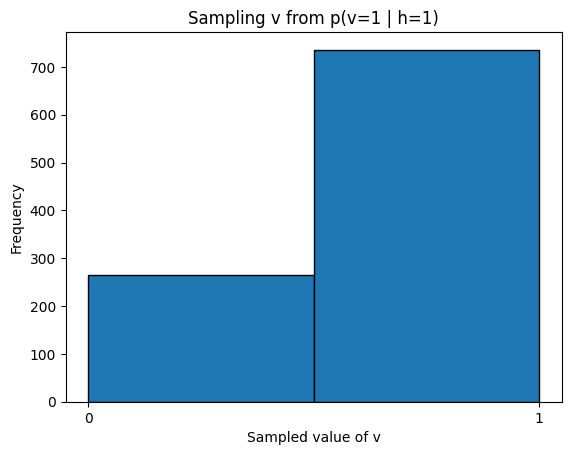

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Parameters
W = 2.0     # weight
b = -1.0    # visible bias
h = 1       # hidden unit state

# Compute activation
activation = W * h + b
p_v_given_h = sigmoid(activation)
print(f"p(v=1 | h=1) = {p_v_given_h:.3f}")

# Sample visible unit multiple times
samples = np.random.binomial(n=1, p=p_v_given_h, size=1000)

# Plot the result
plt.hist(samples, bins=2, edgecolor='black')
plt.xticks([0, 1])
plt.xlabel("Sampled value of v")
plt.ylabel("Frequency")
plt.title("Sampling v from p(v=1 | h=1)")
plt.show()

In [4]:
pip install torch torchvision matplotlib

  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.5.147-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.3.1.170-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nvjitlink_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached nvidia_cublas_

Epoch 1/20 complete
Epoch 2/20 complete
Epoch 3/20 complete
Epoch 4/20 complete
Epoch 5/20 complete
Epoch 6/20 complete
Epoch 7/20 complete
Epoch 8/20 complete
Epoch 9/20 complete
Epoch 10/20 complete
Epoch 11/20 complete
Epoch 12/20 complete
Epoch 13/20 complete
Epoch 14/20 complete
Epoch 15/20 complete
Epoch 16/20 complete
Epoch 17/20 complete
Epoch 18/20 complete
Epoch 19/20 complete
Epoch 20/20 complete


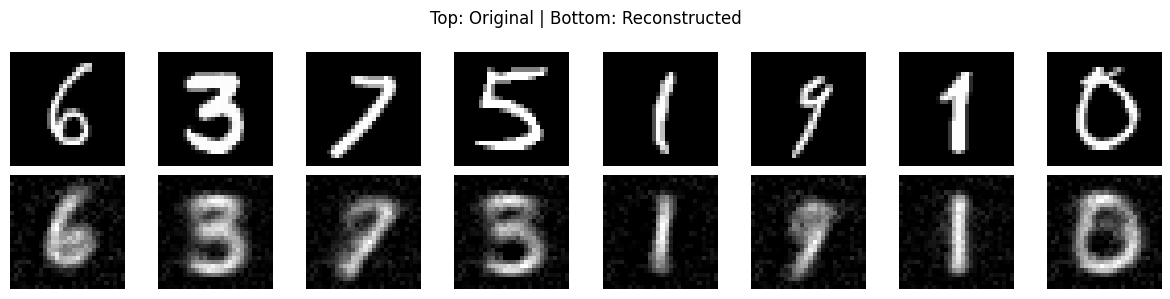

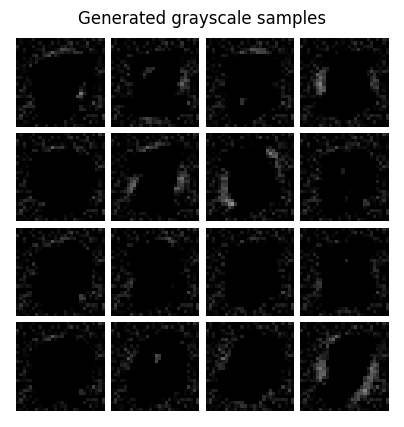

In [8]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
visible_units = 784     # 28x28 images
hidden_units = 256
lr = 0.01
batch_size = 64
epochs = 20
k = 1  # CD-k steps

# Load MNIST (normalized to [0, 1])
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Gaussian-Bernoulli RBM
class GBRBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_vis, n_hid) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_vis))
        self.h_bias = nn.Parameter(torch.zeros(n_hid))

    def sample_h(self, v):
        p_h = torch.sigmoid(torch.matmul(v, self.W) + self.h_bias)
        return p_h, torch.bernoulli(p_h)

    def sample_v(self, h):
        mean_v = torch.matmul(h, self.W.t()) + self.v_bias
        v_sample = mean_v + torch.randn_like(mean_v)  # Gaussian noise
        return mean_v, v_sample

    def cd_step(self, v0):
        p_h0, h0 = self.sample_h(v0)

        # Gibbs Sampling (CD-k)
        v_k = v0
        for _ in range(k):
            _, h_k = self.sample_h(v_k)
            _, v_k = self.sample_v(h_k)

        p_hk, _ = self.sample_h(v_k)

        # Compute gradients
        W_grad = (torch.matmul(v0.t(), p_h0) - torch.matmul(v_k.t(), p_hk)) / v0.size(0)
        vb_grad = torch.mean(v0 - v_k, dim=0)
        hb_grad = torch.mean(p_h0 - p_hk, dim=0)

        # Apply gradients manually
        self.W.data += lr * W_grad
        self.v_bias.data += lr * vb_grad
        self.h_bias.data += lr * hb_grad

        return v_k.detach(), v0.detach()

    def reconstruct(self, v):
        p_h, h = self.sample_h(v)
        mean_v, _ = self.sample_v(p_h)
        return mean_v.clamp(0, 1)

    def generate(self, n_samples=16):
        h = torch.bernoulli(torch.rand(n_samples, hidden_units).to(device))
        mean_v = torch.matmul(h, self.W.t()) + self.v_bias
        return mean_v.view(-1, 1, 28, 28).clamp(0, 1)

rbm = GBRBM(visible_units, hidden_units).to(device)

# Training loop
for epoch in range(epochs):
    for i, (batch, _) in enumerate(train_loader):
        v0 = batch.view(-1, visible_units).to(device)
        rbm.cd_step(v0)
    print(f"Epoch {epoch+1}/{epochs} complete")

# --- Reconstruction: Show original vs. reconstructed images ---
def show_reconstruction():
    test_batch, _ = next(iter(train_loader))
    test_imgs = test_batch[:8].to(device)
    test_flat = test_imgs.view(-1, visible_units)
    recon = rbm.reconstruct(test_flat)

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(test_imgs[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].view(28, 28).cpu().detach(), cmap='gray')
        axes[1, i].axis('off')
    plt.suptitle("Top: Original | Bottom: Reconstructed")
    plt.tight_layout()
    plt.show()

show_reconstruction()

# --- Generate new samples from random hidden vectors ---
def show_generated_samples():
    samples = rbm.generate(16)
    grid_img = torchvision.utils.make_grid(samples.cpu(), nrow=4, pad_value=1)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title("Generated grayscale samples")
    plt.axis('off')
    plt.show()

show_generated_samples()

Epoch 1, Loss: 0.0695
Epoch 2, Loss: 0.0677
Epoch 3, Loss: 0.0636
Epoch 4, Loss: 0.0581
Epoch 5, Loss: 0.0546


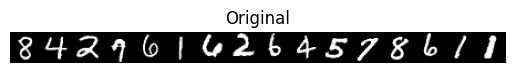

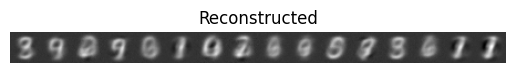

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST
data_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor()
                   ])),
    batch_size=64, shuffle=True
)

# mcRBM Definition
class mcRBM(nn.Module):
    def __init__(self, visible_size=784, mean_hidden=128, cov_hidden=64):
        super(mcRBM, self).__init__()
        self.D = visible_size
        self.M = mean_hidden
        self.C = cov_hidden

        # Mean part (Gaussian RBM)
        self.Wm = nn.Parameter(torch.randn(self.M, self.D) * 0.01)
        self.b = nn.Parameter(torch.zeros(self.D))  # visible bias
        self.cm = nn.Parameter(torch.zeros(self.M))  # mean hidden bias

        # Covariance part
        self.R = nn.Parameter(torch.randn(self.C, self.D) * 0.01)  # filters
        self.cc = nn.Parameter(torch.zeros(self.C))  # covariance hidden bias

    def mean_hidden_probs(self, v):
        v_centered = v - self.b
        activation = F.linear(v_centered, self.Wm, self.cm)
        return torch.sigmoid(activation)

    def cov_hidden_probs(self, v):
        filt_proj = F.linear(v, self.R)  # (B, C)
        activation = (filt_proj ** 2) + self.cc
        return torch.sigmoid(activation)

    def sample_hidden(self, probs):
        return torch.bernoulli(probs)

    def reconstruct(self, v):
        h_mean = self.mean_hidden_probs(v)
        recon = F.linear(h_mean, self.Wm.t()) + self.b
        return recon

    def gibbs_step(self, v):
        h_mean_prob = self.mean_hidden_probs(v)
        h_mean = self.sample_hidden(h_mean_prob)

        h_cov_prob = self.cov_hidden_probs(v)
        h_cov = self.sample_hidden(h_cov_prob)

        # Reconstruction
        v_mean = F.linear(h_mean, self.Wm.t()) + self.b
        v_recon = v_mean  # No noise added here
        return v_recon.detach()

    def forward(self, v):
        return self.reconstruct(v)

# Training settings
model = mcRBM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(data_loader):
        data = data.view(-1, 784).to(device)

        # Positive phase
        v0 = data
        h0_mean = model.mean_hidden_probs(v0)

        # Negative phase (reconstruction)
        v1 = model.gibbs_step(v0)
        h1_mean = model.mean_hidden_probs(v1)

        # Loss: CD approximation to negative log-likelihood
        positive_grad = torch.matmul(h0_mean.t(), v0)
        negative_grad = torch.matmul(h1_mean.t(), v1)

        dWm = (positive_grad - negative_grad) / v0.size(0)
        db = torch.mean(v0 - v1, dim=0)
        dcm = torch.mean(h0_mean - h1_mean, dim=0)

        # Update manually
        model.Wm.data += 1e-3 * dWm
        model.b.data += 1e-3 * db
        model.cm.data += 1e-3 * dcm

        # Skip updating R and cc (optional: can freeze or implement CD)
        batch_loss = torch.mean((v0 - v1) ** 2).item()
        total_loss += batch_loss

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(data_loader):.4f}")

# Visualization
def show_images(imgs, title):
    imgs = imgs.view(-1, 1, 28, 28).cpu().detach()
    grid = torch.cat([imgs[i] for i in range(16)], dim=2).squeeze()
    plt.imshow(grid.numpy(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

sample_data = next(iter(data_loader))[0][:16].view(-1, 784).to(device)
recon_data = model(sample_data)

show_images(sample_data, "Original")
show_images(recon_data, "Reconstructed")